# Can we trust the confidence score?

Every label the model produces comes with a **confidence** — the model's own claim
about how sure it is. If that number were trustworthy we could use it to catch
mistakes automatically.

Five steps to find out whether it is.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import (
    containment, extract_gold, resolve_old_gt_path, tokenize,
)

MODELS = ['llama3.1:8b', 'gemma4:e4b', 'llama3.3:70b']
EXTRACTOR, SAMPLES = 'pdfplumber', range(1, 11)

pd.set_option('display.max_colwidth', 62)
INK, MUTED, SURFACE, GRID = '#111111', '#52514e', '#fcfcfb', '#e6e6e2'
COLOUR = dict(zip(MODELS, ['#2a78d6', '#eb6834', '#1baf7a']))
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.titleweight': 'bold',
    'legend.frameon': False,
})
print('ready')


ready


## Step 1 — Read what the model produced

The model reads the PDF **line by line** and gives every line a label and a
confidence. That is what sits in the labeled JSON files.

First, simply count what is there.


In [2]:
raw = {}
for m in MODELS:
    raw[m] = {n: json.loads(P.labeled_path(P.make_tag(m, EXTRACTOR), n)
                            .read_text(encoding='utf-8')) for n in SAMPLES}

counts = pd.DataFrame([
    {'model': m,
     'lines the model labeled': sum(len(v) for v in raw[m].values()),
     'documents': len(raw[m])}
    for m in MODELS]).set_index('model')
display(counts)

print('one line, exactly as it is stored:')
example = raw[MODELS[0]][1][3]
print(json.dumps({k: example[k] for k in ('text', 'label', 'confidence')},
                 indent=2, ensure_ascii=False)[:400])


,lines the model labeled,documents
model,,
llama3.1:8b,729,10
gemma4:e4b,729,10
llama3.3:70b,729,10


one line, exactly as it is stored:
{
  "text": "This secondary data analysis project will analyze deidentified data from 48,218 participants from eight studies",
  "label": "answer.text",
  "confidence": 1.0
}


Every model was given the same 729 lines, so any difference later is the model.
Each line carries its own label and its own confidence.


## Step 2 — Join the lines back into items

A paragraph in the PDF is several lines. The annotation records it as **one item**.
So before comparing anything, the lines are put back together — neighbouring lines
carrying the **same label** become one item:

```
line   'Sufficient data from those datasets…'   answer.text
line   'findings described in the Aims…'        answer.text
line   'about other studies.'                   answer.text
                       ↓  same label, so they join
item   'Sufficient data … about other studies.' answer.text
```

This is not a special rule for this notebook — it is exactly what the pipeline
already does when it builds its final output.


In [3]:
def join_lines(blocks):
    """Neighbouring lines with the same label become one item."""
    items, cur = [], None
    for b in blocks:
        lab = b.get('label')
        conf = float(b.get('confidence', 1.0))
        if cur and cur['label'] == lab:
            cur['text'] += ' ' + b['text']
            cur['line_confidences'].append(conf)
        else:
            if cur:
                items.append(cur)
            cur = {'label': lab, 'text': b['text'], 'line_confidences': [conf]}
    if cur:
        items.append(cur)
    return items


items = {m: {n: join_lines(raw[m][n]) for n in SAMPLES} for m in MODELS}

shrink = pd.DataFrame([
    {'model': m,
     'lines in': sum(len(v) for v in raw[m].values()),
     'items out': sum(len(v) for v in items[m].values())}
    for m in MODELS]).set_index('model')
shrink['lines per item'] = shrink['lines in'] / shrink['items out']
display(shrink.style.format({'lines per item': '{:.1f}'}))


,lines in,items out,lines per item
model,,,
llama3.1:8b,729,461,1.6
gemma4:e4b,729,164,4.4
llama3.3:70b,729,187,3.9


A model that keeps the same label through a paragraph produces **few, long** items.
One that changes its mind mid-paragraph leaves the paragraph in pieces — more items,
shorter ones. That shows up directly in the `lines per item` column.


## Step 3 — Give each item one confidence: the lowest of its lines

An item is built from several lines, each with its own confidence. We take the
**lowest** one.

The reason: a paragraph is only as trustworthy as its shakiest line. If four lines
were confident and one was a guess, the paragraph contains a guess.


In [4]:
# A real item, and the line confidences it was built from.
demo = max(items[MODELS[0]][1], key=lambda it: len(it['line_confidences']))
print(f"an item made of {len(demo['line_confidences'])} lines")
print(f"  label            : {demo['label']}")
print(f"  line confidences : {demo['line_confidences']}")
print(f"  lowest           : {min(demo['line_confidences'])}  <- the item's confidence")
print(f"  text             : {demo['text'][:90]!r}")


an item made of 12 lines
  label            : answer.text
  line confidences : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  lowest           : 1.0  <- the item's confidence
  text             : '(i) the SOL-VIDA Study – Data requests may be made by following instructions on the Hispan'


### Now compare every item with the annotation

Each item is matched to the annotation paragraph it belongs to, and we check whether
the label agrees. Items too short to place, or matching no paragraph, are left out —
there is nothing to check them against.


In [5]:
rows = []
for n in SAMPLES:
    gold = extract_gold(resolve_old_gt_path(n))
    for m in MODELS:
        for it in items[m][n]:
            tok = tokenize(it['text'])
            if len(tok) < 3:
                continue
            best, true_label = 0.0, None
            for gt, gl in gold:
                c = containment(tok, tokenize(gt))
                if c > best:
                    best, true_label = c, gl
            if best < 0.75:
                continue
            rows.append({
                'model': m, 'sample': n,
                'lines': len(it['line_confidences']),
                'confidence': min(it['line_confidences']),
                'true label': true_label,
                'model said': it['label'],
                'correct': it['label'] == true_label,
                'text': it['text'],
            })
df = pd.DataFrame(rows)

summary = (df.groupby('model')
           .agg(items=('correct', 'size'), right=('correct', 'sum'),
                accuracy=('correct', 'mean'),
                avg_confidence=('confidence', 'mean'))
           .reindex(MODELS))
display(summary.style
        .background_gradient(cmap='Greens', subset=['accuracy'])
        .format({'accuracy': '{:.0%}', 'avg_confidence': '{:.2f}'}))


,items,right,accuracy,avg_confidence
model,,,,
llama3.1:8b,436,214,49%,0.89
gemma4:e4b,155,117,75%,0.95
llama3.3:70b,177,133,75%,0.86


**Compare the last two columns.** Average confidence is what the model *claims*;
accuracy is how often it is actually right. A trustworthy model would have these two
roughly equal. Every model here claims far more than it delivers.


## Step 4 — Calibration: does 90% confidence mean right 90% of the time?

Group the items by the confidence claimed, then check how often each group was
actually right.

- A model saying **0.9** on a hundred items should be right on about **ninety**.
- If it is right on sixty, it is **over-confident** by 30 points.

**ECE** (Expected Calibration Error) is just the average of those gaps, weighted by
how many items are in each group. **0 is perfect; bigger is worse.**


In [6]:
EDGES = [0, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0001]
NAMES = ['below 0.6', '0.6–0.7', '0.7–0.8', '0.8–0.9', '0.9–0.95', '0.95–1.0']


def calibration(d):
    """Per confidence group: how many items, what they claimed, how often right."""
    g = d.copy()
    g['group'] = pd.cut(g['confidence'], bins=EDGES, labels=NAMES, right=False)
    t = (g.groupby('group', observed=True)
         .agg(items=('correct', 'size'), claimed=('confidence', 'mean'),
              actually_right=('correct', 'mean')))
    t['gap'] = t['actually_right'] - t['claimed']
    return t


def ece(d):
    """Average gap between claim and reality, weighted by group size."""
    t = calibration(d)
    return (t['items'] / t['items'].sum() * t['gap'].abs()).sum()


for m in MODELS:
    t = calibration(df[df['model'] == m])
    display(t.style
            .set_caption(f'{m}   —   ECE = {ece(df[df["model"] == m]):.2f}')
            .set_table_styles([{'selector': 'caption',
                                'props': [('caption-side', 'top'),
                                          ('font-weight', '700'),
                                          ('font-size', '112%'),
                                          ('text-align', 'left'),
                                          ('color', INK)]}])
            .background_gradient(cmap='RdYlGn', subset=['gap'], vmin=-0.5, vmax=0.5)
            .format({'claimed': '{:.2f}', 'actually_right': '{:.0%}',
                     'gap': '{:+.0%}'}))
    print()


,items,claimed,actually_right,gap
group,,,,
below 0.6,10,0.31,90%,+59%
0.6–0.7,18,0.62,39%,-23%
0.7–0.8,23,0.71,65%,-6%
0.8–0.9,69,0.81,13%,-68%
0.9–0.95,100,0.90,52%,-38%
0.95–1.0,216,0.98,56%,-42%


,items,claimed,actually_right,gap
group,,,,
0.8–0.9,12,0.81,17%,-65%
0.9–0.95,33,0.90,76%,-14%
0.95–1.0,110,0.98,82%,-16%


,items,claimed,actually_right,gap
group,,,,
0.6–0.7,4,0.60,0%,-60%
0.7–0.8,28,0.70,82%,+12%
0.8–0.9,47,0.80,70%,-10%
0.9–0.95,45,0.90,67%,-23%
0.95–1.0,53,1.00,89%,-11%


The `gap` column is the whole story: **actual accuracy minus claimed confidence.**
Red means the model claimed more than it delivered.

Below, the same thing as a picture. The dashed line is perfect honesty — a dot on it
means the claim matched reality. **Dots below the line are over-confidence.**


saved -> Report-doc\confidence_calibration.png


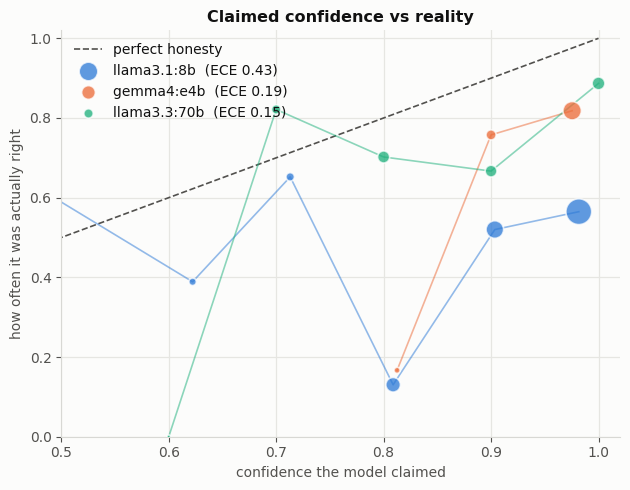

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.plot([0, 1], [0, 1], '--', color=MUTED, linewidth=1.2,
        label='perfect honesty')

for m in MODELS:
    t = calibration(df[df['model'] == m])
    # Dot size shows how many items sit behind each point — a point built
    # from 4 items should not read as strongly as one built from 200.
    ax.scatter(t['claimed'], t['actually_right'], s=t['items'] * 1.6,
               color=COLOUR[m], alpha=0.75, edgecolor='white', linewidth=1.2,
               label=f'{m}  (ECE {ece(df[df["model"] == m]):.2f})', zorder=3)
    ax.plot(t['claimed'], t['actually_right'], color=COLOUR[m],
            linewidth=1.2, alpha=0.5, zorder=2)

ax.set_xlim(0.5, 1.02)
ax.set_ylim(0, 1.02)
ax.set_xlabel('confidence the model claimed')
ax.set_ylabel('how often it was actually right')
ax.set_title('Claimed confidence vs reality')
ax.grid(color=GRID, linewidth=0.9)
ax.set_axisbelow(True)
ax.legend(loc='upper left')
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()
out = Path('Report-doc/confidence_calibration.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=SURFACE)
print(f'saved -> {out}')
plt.show()


## Step 5 — Four kinds of item, with real examples

Splitting every item by confidence (high = 0.9 or more) and by whether it was right:

| | correct | wrong |
|---|---|---|
| **high confidence** | fine — sure and right | **the dangerous box** — sure and wrong |
| **low confidence** | over-cautious, harmless | fine — unsure and wrong |

For confidence to be useful, the top-right box should be nearly empty: mistakes
should arrive with low confidence, where we can catch them.


In [8]:
df['high confidence'] = df['confidence'] >= 0.9

for m in MODELS:
    d = df[df['model'] == m]
    box = pd.crosstab(d['high confidence'].map({True: 'high (>= 0.9)',
                                                False: 'low (< 0.9)'}),
                      d['correct'].map({True: 'correct', False: 'wrong'}))
    box = box.reindex(index=['high (>= 0.9)', 'low (< 0.9)'],
                      columns=['correct', 'wrong'], fill_value=0)
    display(box.style.set_caption(m)
            .set_table_styles([{'selector': 'caption',
                                'props': [('caption-side', 'top'),
                                          ('font-weight', '700'),
                                          ('font-size', '112%'),
                                          ('text-align', 'left'),
                                          ('color', INK)]}])
            .background_gradient(cmap='Reds', axis=None))
    print()


correct,correct,wrong
high confidence,,
high (>= 0.9),174,142
low (< 0.9),40,80


correct,correct,wrong
high confidence,,
high (>= 0.9),115,28
low (< 0.9),2,10


correct,correct,wrong
high confidence,,
high (>= 0.9),77,21
low (< 0.9),56,23


### One example from each box

Using **llama3.1:8b**. The second row is the one that matters.


In [9]:
M = MODELS[0]
d = df[df['model'] == M]

picks = []
for hi, ok, name in ((True, True, 'high confidence + CORRECT'),
                     (True, False, 'high confidence + WRONG'),
                     (False, True, 'low confidence + correct'),
                     (False, False, 'low confidence + wrong')):
    sub = d[(d['high confidence'] == hi) & (d['correct'] == ok)]
    if len(sub):
        r = sub.sort_values('confidence', ascending=not hi).iloc[0]
        picks.append({'case': name, 'confidence': r['confidence'],
                      'true label': r['true label'], 'model said': r['model said'],
                      'text': r['text'][:70]})
    else:
        picks.append({'case': name, 'confidence': np.nan, 'true label': '—',
                      'model said': '—', 'text': '(none in this box)'})

display(pd.DataFrame(picks).set_index('case').style
        .format({'confidence': '{:.2f}'}, na_rep='—'))


,confidence,true label,model said,text
case,,,,
high confidence + CORRECT,1.00,title,title,DATA MANAGEMENT AND SHARING PLAN
high confidence + WRONG,1.00,question.text,section.title,"B. Scientific data that will be preserved and shared, and the rational"
low confidence + correct,0.10,answer.text,answer.text,The proposed research in this proposal includes both computational and
low confidence + wrong,0.55,section.description,question.text,Data management plans should provide a plan for making all research da


The **high confidence + WRONG** row is the finding. The model is not hedging when it
errs — it is as sure of its mistakes as of its correct answers, so a high score
cannot be used to wave an item through.


## Conclusion

**The confidence score is not reliable enough to accept or reject a label.**

1. Every model **claims more than it delivers** — average confidence sits far above
   actual accuracy (step 3).
2. Calibration confirms it: the gaps are large and negative, and ECE is high for
   every model (step 4).
3. Most mistakes arrive with **high** confidence, so the dangerous box is the
   crowded one (step 5).

**Do not** use confidence to auto-accept a label, and do not drop low-confidence
items — a dropped item becomes a missing item, which costs exactly as much as a
wrong one.

**The one usable signal:** gemma4:e4b has the smallest gap between claim and
reality, so its *lowest*-confidence items are worth sending to a person to check.
Each model's scale is its own, though — a threshold chosen for one means nothing
for another.
